In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.animation as animation
from scipy.interpolate import CubicSpline
from scipy.interpolate import make_interp_spline
from matplotlib.lines import Line2D

In [ ]:
def RK4_ADM(y, dty, dt, x):
  k1 = dty(y, x)
  k2 = dty(y + 0.5*dt*k1, x)
  k3 = dty(y + 0.5*dt*k2, x)
  k4 = dty(y + dt*k3, x)

  y = y + (dt/6)*(k1+2*(k2+k3)+k4)
  return y

def dxy_2nd_D(y, x, y_left=0.0, y_right=0.0):
    h = x[1] - x[0]
    dyx = np.zeros_like(y)

    # ghost points from Dirichlet BCs
    y_ghost_left = 2 * y_left - y[0]
    y_ghost_right = 2 * y_right - y[-1]

    # centered difference using ghost points
    dyx[1:-1] = (y[2:] - y[:-2]) / (2 * h)
    dyx[0]    = (y[1] - y_ghost_left) / (2 * h)
    dyx[-1]   = (y_ghost_right - y[-2]) / (2 * h)
    return dyx

def dxy_2nd_D_2nd(y, x, y_left=0.0, y_right=0.0): # second order and second differential with Dirichlet BCs
    h = x[1] - x[0]
    dyx = np.zeros_like(y)

    # ghost points from Dirichlet BCs due to staggered grid
    y_ghost_left = 2 * y_left - y[0]
    y_ghost_right = 2 * y_right - y[-1]

    # centered difference using ghost points
    dyx[1:-1] = (y[2:] + y[:-2] - 2*y[1:-1]) / (h*h)
    dyx[0]    = (y[1] + y_ghost_left -2*y[0] ) / (h*h)
    dyx[-1]   = (y[-2] + y_ghost_right -2*y[-1] ) / (h*h)
    return dyx

def dxy_2nd_N(y, x, y_left=0.0, y_right=0.0):

    h = x[1] - x[0]
    dyx = np.zeros_like(y)

    # ghost points from Neumann BCs: g_left = (y1 - y_-1)/(2h), g_right = (y_N - y_{N-2})/(2h)
    y_ghost_left  = y[1]  - 2.0*h*y_left
    y_ghost_right = 2.0*h*y_right + y[-2]

    # centered differences
    dyx[1:-1] = (y[2:] - y[:-2]) / (2.0*h)
    dyx[0]    = (y[1] - y_ghost_left)  / (2.0*h)
    dyx[-1]   = (y_ghost_right - y[-2]) / (2.0*h)
    return dyx

def dxy_2nd_N_2nd(y, x, y_left = 0.0, y_right = 0.0):
    h = x[1] - x[0]
    inv_h2 = 1.0 / (h*h)

    # Left ghost: (y0 - y_ghost)/(2h) = dydx_left
    y_ghost_left = y[0] - 2.0*h*y_left

    # Right ghost: (y_ghost - y_last)/(2h) = dydx_right
    y_ghost_right = y[-1] + 2.0*h*y_right

    # Extend grid
    y_ext = np.concatenate(([y_ghost_left], y, [y_ghost_right]))

    # Centered second difference
    return (y_ext[2:] - 2*y_ext[1:-1] + y_ext[:-2]) * inv_h2

def make_staggeredx(xnum, end):
  x = np.linspace(0, (xnum-1)/xnum , xnum)
  x += 1/(2*xnum)
  x = x*end
  return x



def get_grad(vars, grid): # conformal version
  gradishs = np.ndarray(shape = [4,len(grid)])
  gradishs[0] = dxy_2nd_N(vars[0], grid, y_left = 0, y_right = 0)
  gradishs[1] = dxy_2nd_N(vars[1], grid, y_left = 0, y_right = 0)
  gradishs[2] = dxy_2nd_N(vars[2], grid, y_left = 0, y_right = 0)
  gradishs[3] = dxy_2nd_N(vars[3], grid, y_left = 0, y_right = 0)
  return (gradishs)



def get_rates(vars, grid, mass = 1): # this version is for a conformal a and b for isotropic schwartzchild
  lapse, shift = vars[4], vars[5]
  rates = np.ndarray(shape = [6,len(grid)], dtype=np.double)

  ######Shit for ease later in function
  ####################################################################################################
  r_squared = grid * grid
  conformal_scaling = (1 + (mass/(2*grid)))
  conformal_scaling4 = conformal_scaling**4
  conformal_scaling4_1st = -2*mass * (conformal_scaling**3) / r_squared
  conformal_scaling4_2nd = (mass/r_squared) * (((4*conformal_scaling**3)/grid) + ((3*mass*conformal_scaling**2)/r_squared))
  ####################################################################################################
  grad_shift = dxy_2nd_D(shift, grid)
  gradishs = get_grad(vars, grid)
  grad_lapse = dxy_2nd_D(lapse, grid, y_left = 1, y_right = 1)
  second_lapse = dxy_2nd_D_2nd(lapse, grid, y_left = 1, y_right = 1)

  #rewrite a as a function of conformal stuff
  a = conformal_scaling4 * vars[0]
  a_1st = conformal_scaling4_1st*vars[0] + conformal_scaling4*gradishs[0]

  #rewrite b as a function of conformal stuff
  b = conformal_scaling4 * r_squared *vars[1]
  b_1st = (conformal_scaling4_1st * r_squared*vars[1]) + (conformal_scaling4* (2*grid*vars[1] + r_squared*gradishs[1])) # fine
  b_2nd = (conformal_scaling4_2nd*r_squared*vars[1]) + 2*(conformal_scaling4_1st*(2*grid*vars[1] + r_squared*gradishs[1])) + (conformal_scaling4*(2*vars[1] + 4*grid*gradishs[1] + r_squared*dxy_2nd_N_2nd(vars[1], grid, y_left = 0, y_right = 0)))

  #rewrite c as a function of conformal stuff
  c = conformal_scaling4 * vars[2]
  c_1st = conformal_scaling4_1st*vars[2] + conformal_scaling4*gradishs[2]

  #rewrite d as a function of conformal stuff
  d = conformal_scaling4 * r_squared *vars[3]
  d_1st = (conformal_scaling4_1st * r_squared*vars[3]) + (conformal_scaling4* (2*grid*vars[3] + r_squared*gradishs[3])) # fine


  #actual PDEs
  rates[0] = (shift * a_1st) + 2*(a*grad_shift - lapse*c)
  rates[1] = (shift * b_1st - 2*lapse*d)

  rates[2] = lapse* (-(c*c/a) + ((2*d*c)
  + 0.5*((b_1st*b_1st)/(b) + (a_1st*b_1st)/(a)) - (b_2nd))/b)
  + (2*grad_shift*c) + (shift * c_1st) - second_lapse + 0.5*(a_1st*grad_lapse/a)
  rates[3] = (1/a)*((c*d*lapse) + (0.25*a_1st*b_1st*lapse/(a)) - (0.5*b_2nd*lapse) - (0.5*grad_lapse*b_1st/a)) + lapse + shift*d_1st

  #change back to conformal rates
  rates[0] /= conformal_scaling4
  rates[1] /= (conformal_scaling4 * r_squared)
  rates[2] /= conformal_scaling4
  rates[3] /= (conformal_scaling4 * r_squared)

  K = 0#c/a + 2*d/b
  rates[4] = - 2*(lapse) * K
  rates[4][-1] = 0
  rates[5] = np.zeros(len(grid))
  return (rates)

In [ ]:
xnum = 1000

vars = np.ndarray(shape = [6,xnum], dtype=np.double) # a, b, c and d are the "ith" row
gradishs = np.ndarray(shape = [6,xnum], dtype=np.double) # partial derivatives with respect to r
rates = np.ndarray(shape = [6,xnum], dtype=np.double) # partial derivatives with respect to time for the vars


x = make_staggeredx(xnum,50)

conformal_scaling = (1 + (1/(2*x)))
conformal_scaling4 = conformal_scaling**4

vars[0] = np.ones(xnum, dtype=np.double)
vars[1] = np.ones(xnum, dtype=np.double)
vars[2] = np.zeros(xnum, dtype=np.double)
vars[3] = np.zeros(xnum, dtype=np.double)
vars[4] = np.full(xnum, 1)#lapse
vars[5] = np.full(xnum, 0)#shift

rates = get_rates(vars,x)

In [ ]:
coord_relation = []
a, b, c, d, lap = [], [], [], [], []
T_max = 20
dt = 0.1*(x[1]-x[0])
t = 0

saverate = 2

print(dt)
print(T_max/dt)



while (t < T_max):
  if not np.isnan(vars).any():
    vars = RK4_ADM(vars, get_rates, dt, x)
    rates = get_rates(vars,x)
    t += dt
  else:
    print(t)
    break

  if abs(t*saverate - round(t*saverate)) < 1e-9:  # tolerance for float comparison
      integer_time = int(round(t))   # e.g. 1, 2, 3 ...
      if integer_time > 0:
          a.append(vars[0])
          b.append(vars[1])
          c.append(vars[2])
          d.append(vars[3])
          lap.append(vars[4])

          coord_relation.append(vars[1])

conformal_scaling = (1 + (1/(2*x)))
conformal_scaling4 = conformal_scaling**4

coordinate_change = x*(conformal_scaling**2)
coord_relation = np.sqrt((coord_relation)*conformal_scaling4*x*x)

0.005
4000.0


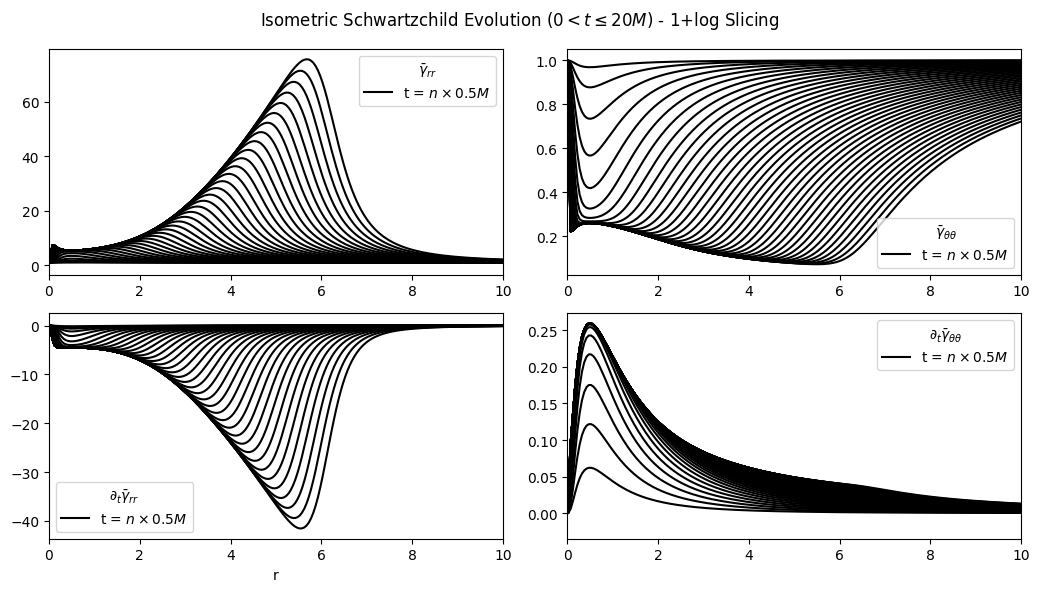

In [ ]:
fig, ax = plt.subplots(2,2, figsize = (10.5, 6))

for i in range(len(a)):
  ax[0][0].plot(x, a[i],label = r'$a$', color = 'black', linestyle = 'solid')
  ax[0][1].plot(x, b[i],label = r'$b$', color = 'black', linestyle = 'solid')
  ax[1][0].set_xlabel('r')

  ax[1][0].plot(x, c[i],label = r'$c$', color = 'black', linestyle = 'solid')
  ax[1][1].plot(x, d[i],label = r'$d$', color = 'black', linestyle = 'solid')

#line names
custom_lines = [Line2D([0], [0], color = 'black', linestyle = 'solid')]

ax[0][0].legend(custom_lines, [r't = $n\times0.5M$'], title = r'$\bar\gamma_{rr}$')
ax[0][1].legend(custom_lines, [r't = $n\times0.5M$'], title = r'$\bar\gamma_{\theta\theta}$')
ax[1][0].legend(custom_lines, [r't = $n\times0.5M$'], title = r'$\partial_t \bar\gamma_{rr}$')
ax[1][1].legend(custom_lines, [r't = $n\times0.5M$'], title = r'$\partial_t \bar\gamma_{\theta\theta}$')

ax[0][0].set_xlim(left = 0, right = 10)
ax[0][1].set_xlim(left = 0, right = 10)
ax[1][0].set_xlim(left = 0, right = 10)
ax[1][1].set_xlim(left = 0, right = 10)

fig.suptitle(r'Isometric Schwartzchild Evolution $(0 < t \leq 20M)$ - 1+log Slicing')
fig.tight_layout()

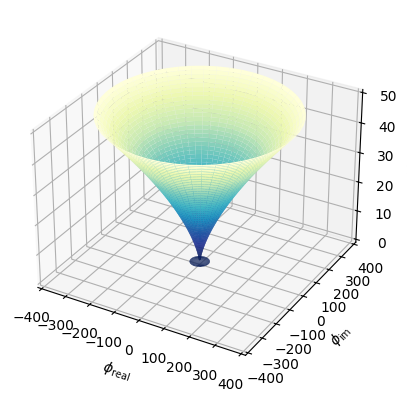

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Create the mesh in polar coordinates and compute corresponding Z.
r = np.sqrt((coord_relation[0])*conformal_scaling4*x*x)
p = np.linspace(0, 2*np.pi, 50)
R, P = np.meshgrid(r, p)
Z_1d = x

# Reshape Z to be 2-dimensional, matching the shape of R and P
Z = np.broadcast_to(Z_1d, R.shape)

# Express the mesh in the cartesian system.
X, Y = R*np.cos(P), R*np.sin(P)

# Plot the surface.
ax.plot_surface(X, Y, Z, cmap=plt.cm.YlGnBu_r)

# Tweak the limits and add latex math labels.
#ax.set_zlim(0, 5)
#ax.set_xlim(-50, 50)
#ax.set_ylim(-50, 50)
ax.set_xlabel(r'$\phi_\mathrm{real}$')
ax.set_ylabel(r'$\phi_\mathrm{im}$')
ax.set_zlabel(r'$V(\phi)$')

plt.show()

2.1979864545712756e-18


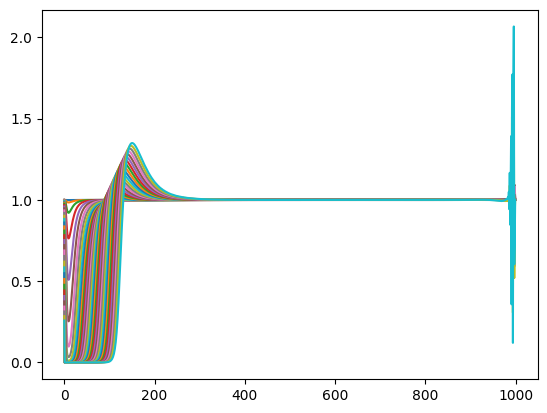

In [ ]:
for i in range(len(lap)):
  plt.plot(lap[i])

print(np.min(lap))

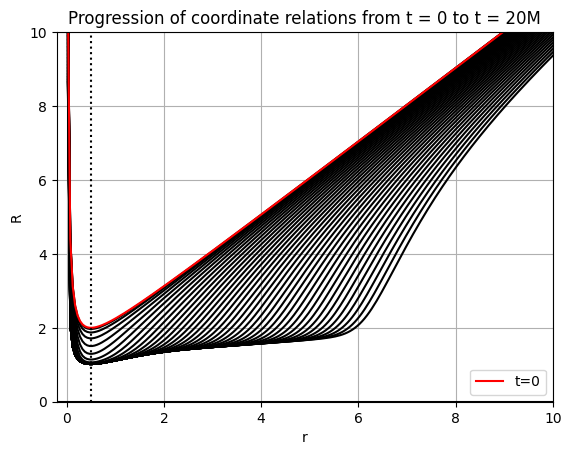

In [ ]:
for row in coord_relation:
  plt.plot(x,row, color = 'black',linestyle = 'solid')

plt.plot(x,coordinate_change, color = 'red', linestyle = 'solid', label = 't=0')

plt.axvline(x = 0.5, color = 'black', linestyle = 'dotted')
plt.axhline(y = 0, xmin=0, xmax = 10, color = 'black')
plt.ylim(bottom = 0, top = 10)
plt.xlim(-0.2,10)

plt.legend(loc = 'lower right')
plt.xlabel('r')
plt.ylabel('R')
plt.title('Progression of coordinate relations from t = 0 to t = 20M')
plt.grid()

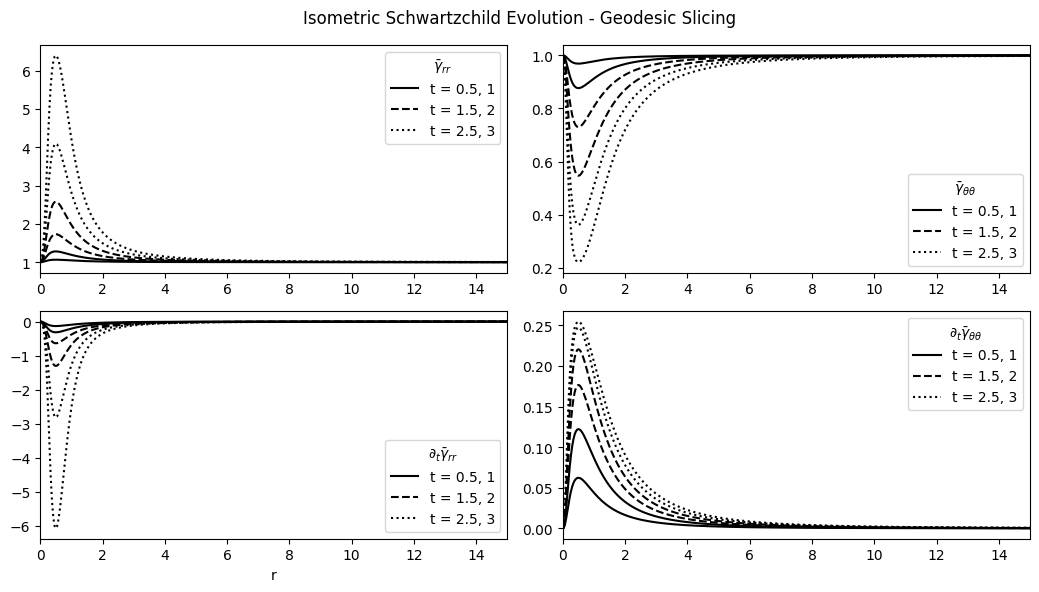

In [ ]:
fig, ax = plt.subplots(2,2, figsize = (10.5, 6))

string_of_styles = ['solid','dashed','dotted']
j = 0

coord_relation = []

for i in range(3001):
  if not np.isnan(vars).any():
    vars = RK4_ADM(vars, get_rates, 0.001, x)
    rates = get_rates(vars,x)
  else:
    print(i*0.001)
    break

  if ((i % 500) == 0) and (i>0):

    ax[0][0].plot(x, vars[0],label = r'$a$', color = 'black', linestyle = string_of_styles[int(np.floor(j))])
    ax[0][1].plot(x, vars[1],label = r'$b$', color = 'black', linestyle = string_of_styles[int(np.floor(j))])
    ax[1][0].set_xlabel('r')

    ax[1][0].plot(x, vars[2],label = r'$c$', color = 'black', linestyle = string_of_styles[int(np.floor(j))])
    ax[1][1].plot(x, vars[3],label = r'$d$', color = 'black', linestyle = string_of_styles[int(np.floor(j))])
    j += 0.5

    coord_relation.append(vars[1])

#line names
custom_lines = [Line2D([0], [0], color = 'black', linestyle = 'solid'),
                Line2D([0], [0], color = 'black', linestyle = 'dashed'),
                Line2D([0], [0], color = 'black', linestyle = 'dotted')]

ax[0][0].legend(custom_lines, [r't = 0.5, 1', r't = 1.5, 2', r't = 2.5, 3'], title = r'$\bar\gamma_{rr}$')
ax[0][1].legend(custom_lines, [r't = 0.5, 1', r't = 1.5, 2', r't = 2.5, 3'], title = r'$\bar\gamma_{\theta\theta}$')
ax[1][0].legend(custom_lines, [r't = 0.5, 1', r't = 1.5, 2', r't = 2.5, 3'], title = r'$\partial_t \bar\gamma_{rr}$')
ax[1][1].legend(custom_lines, [r't = 0.5, 1', r't = 1.5, 2', r't = 2.5, 3'], title = r'$\partial_t \bar\gamma_{\theta\theta}$')

ax[0][0].set_xlim(left = 0, right = 15)
ax[0][1].set_xlim(left = 0, right = 15)
ax[1][0].set_xlim(left = 0, right = 15)
ax[1][1].set_xlim(left = 0, right = 15)

fig.suptitle('Isometric Schwartzchild Evolution - Geodesic Slicing')
fig.tight_layout()

In [ ]:
def initial_vars(num_points, x):
    vars = np.ndarray(shape=[6, num_points], dtype=np.double)
    for i in range(2, 4):
        vars[i] = np.zeros(num_points, dtype=np.double)
    vars[1] = np.ones(num_points, dtype=np.double)
    vars[0] = np.ones(num_points, dtype=np.double)
    vars[4] = np.ones(num_points, dtype=np.double)
    #np.put(vars[4], vars[4].size // 2, 2-1.0001)
    vars[5] = np.zeros(num_points, dtype=np.double)
    return vars

In [ ]:
#dt0 = 0.0001
initial_num = 50
crashtimes = []

for i in range(1,75):
  t = 0
  x = make_staggeredx(initial_num*(i),30)

  dt = 0.1* abs(x[1]-x[0])
  vars = initial_vars(initial_num*(i), x)
  while t < 5: # number of "timesteps"
    if not np.isnan(vars).any():
      vars = RK4_ADM(vars, get_rates, dt, x)
      t += dt
    else:
      print(t)
      crashtimes.append(t)
      break


/tmp/ipython-input-1837801509.py:126: RuntimeWarning: overflow encountered in multiply
  rates[2] = lapse* (-(c*c/a) + ((2*d*c)
/tmp/ipython-input-1837801509.py:126: RuntimeWarning: invalid value encountered in add
  rates[2] = lapse* (-(c*c/a) + ((2*d*c)
/tmp/ipython-input-1837801509.py:129: RuntimeWarning: overflow encountered in multiply
  rates[3] = (1/a)*((c*d*lapse) + (0.25*a_1st*b_1st*lapse/(a)) - (0.5*b_2nd*lapse) - (0.5*grad_lapse*b_1st/a)) + lapse + shift*d_1st
/tmp/ipython-input-1837801509.py:119: RuntimeWarning: invalid value encountered in add
  d_1st = (conformal_scaling4_1st * r_squared*vars[3]) + (conformal_scaling4* (2*grid*vars[3] + r_squared*gradishs[3])) # fine
/tmp/ipython-input-1837801509.py:127: RuntimeWarning: overflow encountered in multiply
  + 0.5*((b_1st*b_1st)/(b) + (a_1st*b_1st)/(a)) - (b_2nd))/b)
/tmp/ipython-input-1837801509.py:127: RuntimeWarning: invalid value encountered in add
  + 0.5*((b_1st*b_1st)/(b) + (a_1st*b_1st)/(a)) - (b_2nd))/b)
/tmp/ipython

3.600000000000002
3.3599999999999923
3.3000000000000025
3.240000000000004
3.2520000000000024
3.2199999999999753
3.2142857142857086
3.19499999999998


/tmp/ipython-input-1837801509.py:49: RuntimeWarning: invalid value encountered in scalar subtract
  dyx[0]    = (y[1] - y_ghost_left)  / (2.0*h)


3.2000000000000197
3.1859999999999586
3.1854545454545176
3.1749999999999545
3.170769230769261
3.162857142857179
3.1680000000000024
3.161250000000025
3.162352941176411
3.1633333333333793
3.1642105263158204
3.162000000000009
3.1657142857142255
3.158181818181877
3.1565217391304494
3.1599999999999437
3.151200000000062
3.1569230769230052
3.15999999999991
3.158571428571506


/tmp/ipython-input-1837801509.py:123: RuntimeWarning: invalid value encountered in multiply
  rates[0] = (shift * a_1st) + 2*(a*grad_shift - lapse*c)


...

3.1505454545455933


/tmp/ipython-input-1837801509.py:127: RuntimeWarning: invalid value encountered in divide
  + 0.5*((b_1st*b_1st)/(b) + (a_1st*b_1st)/(a)) - (b_2nd))/b)
/tmp/ipython-input-1837801509.py:129: RuntimeWarning: invalid value encountered in divide
  rates[3] = (1/a)*((c*d*lapse) + (0.25*a_1st*b_1st*lapse/(a)) - (0.5*b_2nd*lapse) - (0.5*grad_lapse*b_1st/a)) + lapse + shift*d_1st
/tmp/ipython-input-1837801509.py:67: RuntimeWarning: invalid value encountered in subtract
  return (y_ext[2:] - 2*y_ext[1:-1] + y_ext[:-2]) * inv_h2
/tmp/ipython-input-1837801509.py:67: RuntimeWarning: invalid value encountered in add
  return (y_ext[2:] - 2*y_ext[1:-1] + y_ext[:-2]) * inv_h2


3.150000000000098
3.1494736842106437
3.1489655172414817
3.1474576271185835
3.1469999999997644
3.1495081967210994
3.151935483870992
3.1466666666668393
3.1471875000000953
3.147692307692541
3.1472727272728473
3.149552238806159
3.1464705882354815
3.1460869565218554
3.147428571428666
3.147042253521217
3.1483333333334187


/tmp/ipython-input-1837801509.py:7: RuntimeWarning: invalid value encountered in add
  y = y + (dt/6)*(k1+2*(k2+k3)+k4)


3.1463013698632745
3.1500000000002637


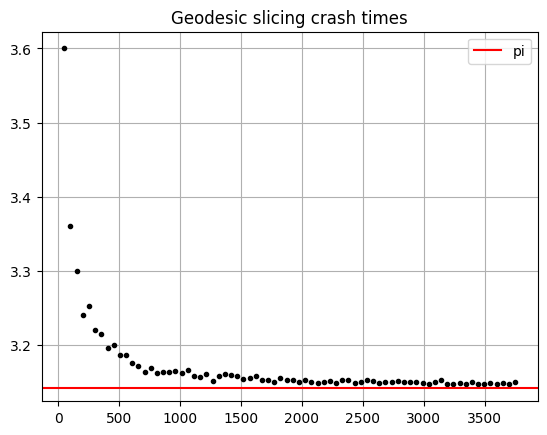

In [ ]:
num = 75
plt.plot(50*np.linspace(1,num,num-1),crashtimes, '.',color = 'black')
plt.axhline(np.pi, color = 'red', label = 'pi')
plt.legend()
plt.title('Geodesic slicing crash times')
plt.grid()